In [1]:
!pip install roboflow

from roboflow import Roboflow
rf = Roboflow(api_key="RnVwPCB8UgjXPHrFvLlO")
project = rf.workspace("roboflow-jvuqo").project("detecting-vehicles-on-aerial-images")
version = project.version(8)
dataset = version.download("yolov9")
                

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 89.9/89.9 kB 4.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.8/66.8 kB 3.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.9/49.9 MB 37.9 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 50.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.2/4.2 MB 59.9 MB/s eta 0:00:0000:0100:01
  Attempting uninstall: idna
    Found existing installation: idna 3.11
    Uninstalling idna-3.11:
      Successfully uninstalled idna-3.11
  Attempting uninstall: opencv-python-headless
    Found existing installation: opencv-python-headless 4.12.0.88
    Uninstalling opencv-python-headless-4.12.0.88:
      Successfully uninstalled opencv-python-headless-4.12.0.88
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
bigframes 2.12.0 requires google-cloud-bigquer


Extracting Dataset Version Zip to Detecting-Vehicles-on-Aerial-Images-8 in yolov9:: 100%|██████████| 449/449 [00:00<00:00, 6585.02it/s]


In [2]:
# Define a function to write text to a file
def write_text_to_file(text, file_path):
    with open(file_path, 'w') as file:
        file.write(text)


text="""
names:
- bus
- cars
- truck
- van

nc: 4


train: /kaggle/working/Detecting-Vehicles-on-Aerial-Images-8/train/images
val: /kaggle/working/Detecting-Vehicles-on-Aerial-Images-8/valid/images

"""

write_text_to_file(text, "output.yaml")

In [9]:
!pip install -q --no-cache-dir \
    torch==2.3.0 torchvision==0.18.0 --extra-index-url https://download.pytorch.org/whl/cu118 \
    "ultralytics>=8.2.0" \
    roboflow \
    pandas==2.1.4 \
    seaborn \
    matplotlib \
    opencv-python-headless \
    pyyaml \
    numpy==1.26.4 \
    scipy==1.13.1

# Verify installations
import torch, numpy as np, pandas as pd, ultralytics
print(f"torch: {torch.__version__}")
print(f"numpy: {np.__version__}")
print(f"pandas: {pd.__version__}")
print(f"ultralytics: {ultralytics.__version__}")
print(f"GPU: {torch.cuda.is_available()}")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 839.7/839.7 MB 186.3 MB/s eta 0:00:0000:0100:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.3/6.3 MB 270.0 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.0/61.0 kB 7.3 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.6/60.6 kB 285.8 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 728.5/728.5 MB 288.8 MB/s eta 0:00:0000:0100:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 142.9/142.9 MB 285.0 MB/s eta 0:00:00a 0:00:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 168.1/168.1 MB 291.2 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.2/12.2 MB 226.8 MB/s eta 0:00:0000:010:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.3/18.3 MB 333.1 MB/s eta 0:00:00a 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 38.6/38.6 MB 222.6 MB/s eta 0:00:00a 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 417.9/417.9 MB 143.4 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

In [11]:
!yolo task=detect  mode=train data=/kaggle/working/output.yaml model=yolo11s.yaml epochs=100 imgsz=640 batch=16

Ultralytics 8.3.233 🚀 Python-3.11.13 torch-2.3.0+cu118 CUDA:0 (Tesla P100-PCIE-16GB, 16269MiB)
engine/trainer: agnostic_nms=False, amp=True, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/kaggle/working/output.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=100, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo11s.yaml, momentum=0.937, mosaic=1.0, multi_scale=False, name=train5, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, patience=100, perspective=0.0, plo

In [12]:
from IPython.display import Image, display


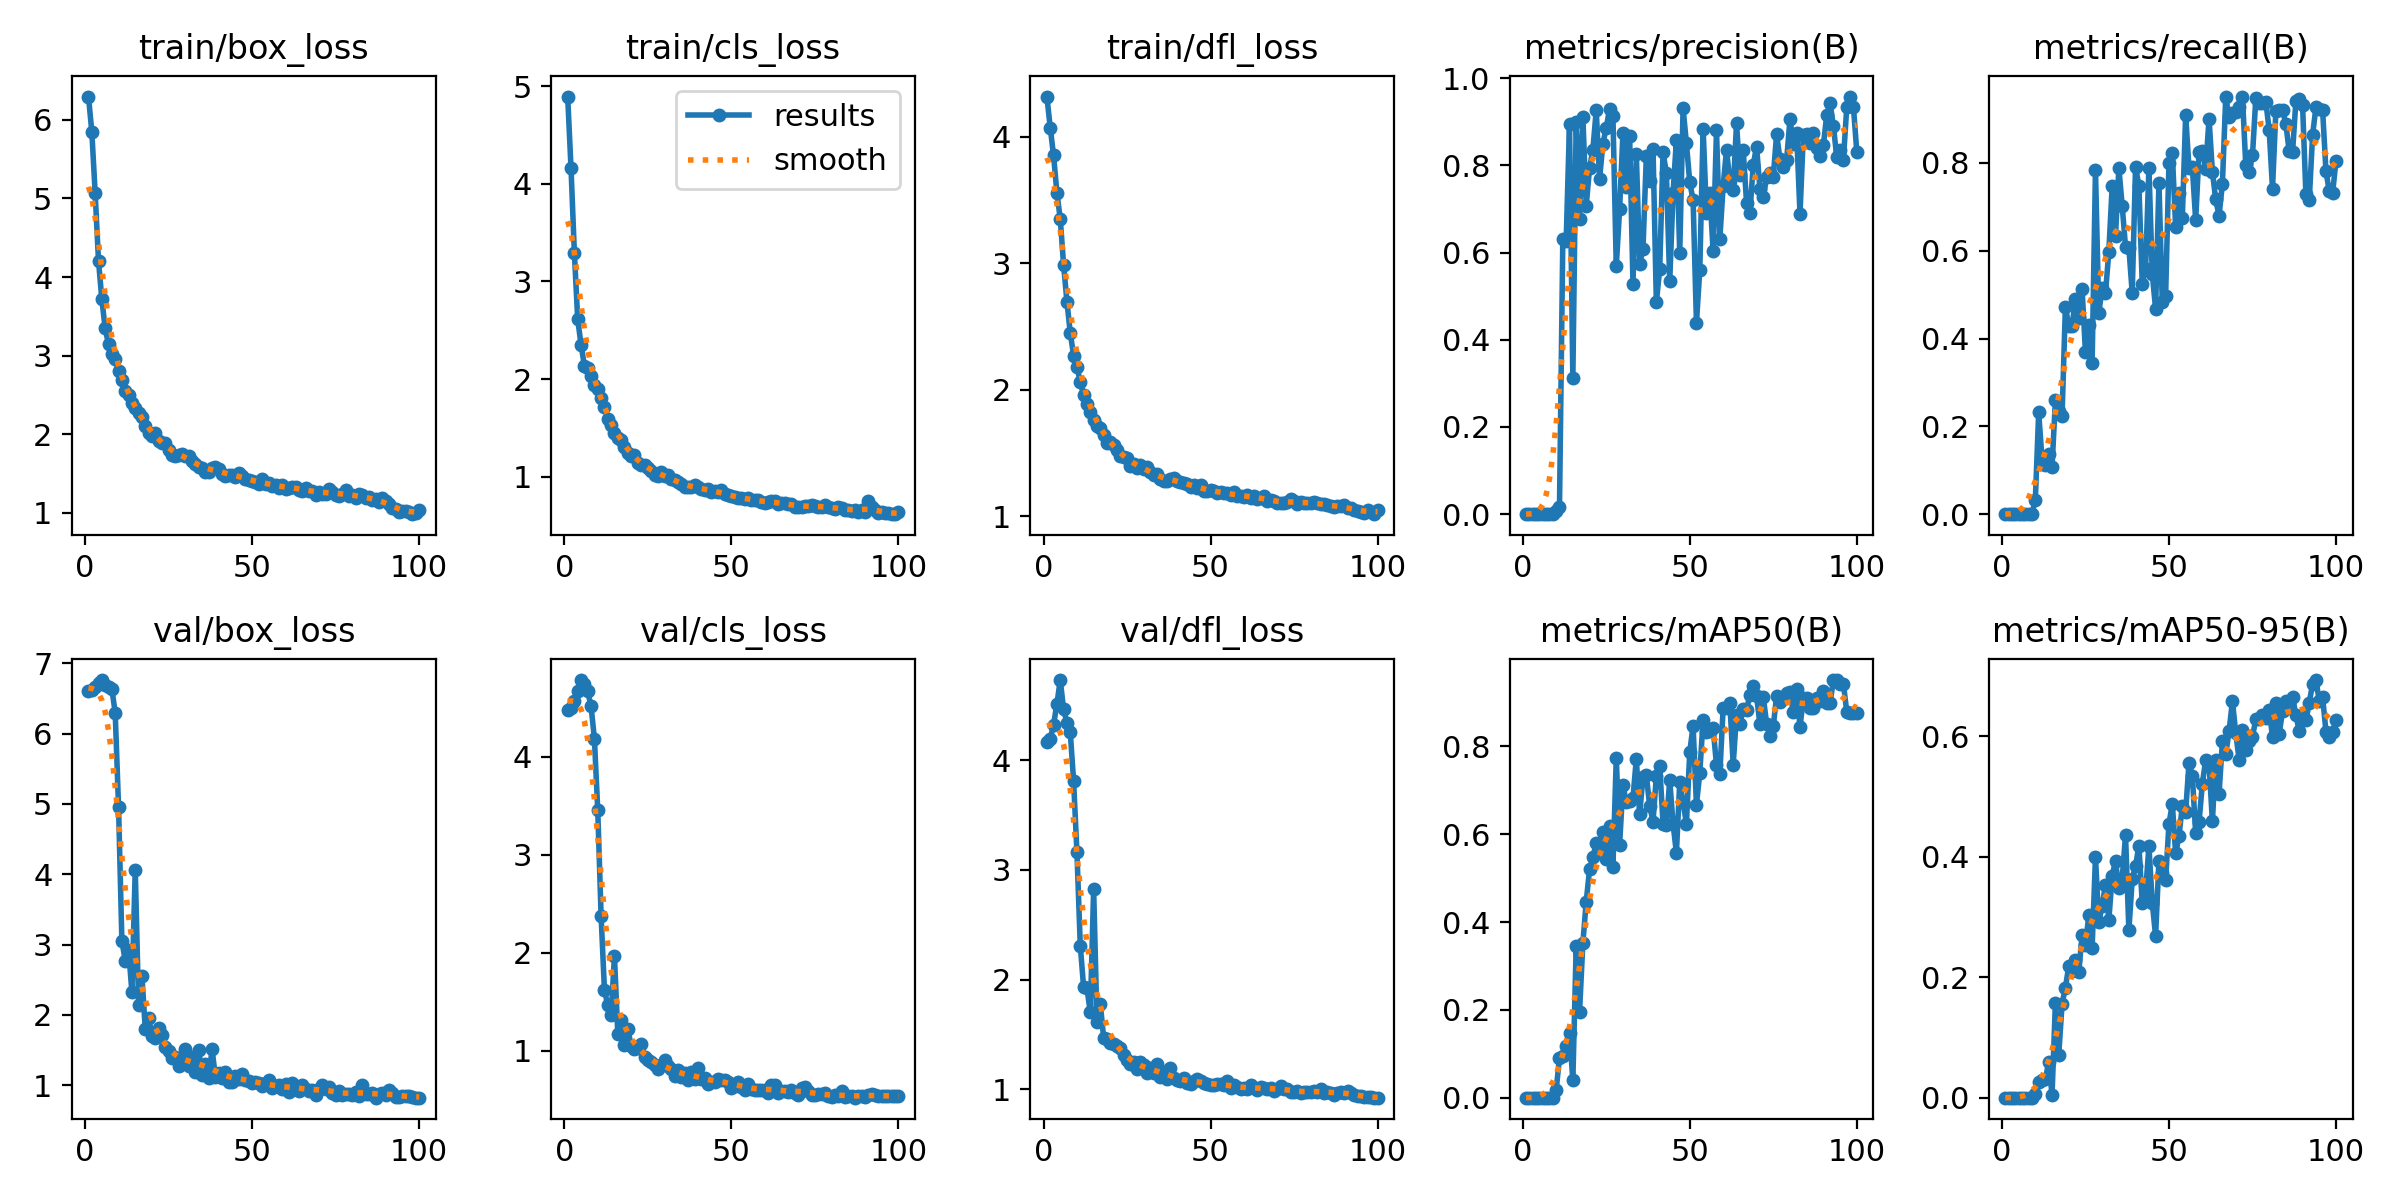

In [13]:
display(Image(filename=f"/kaggle/working/runs/detect/train5/results.png", width=1000))

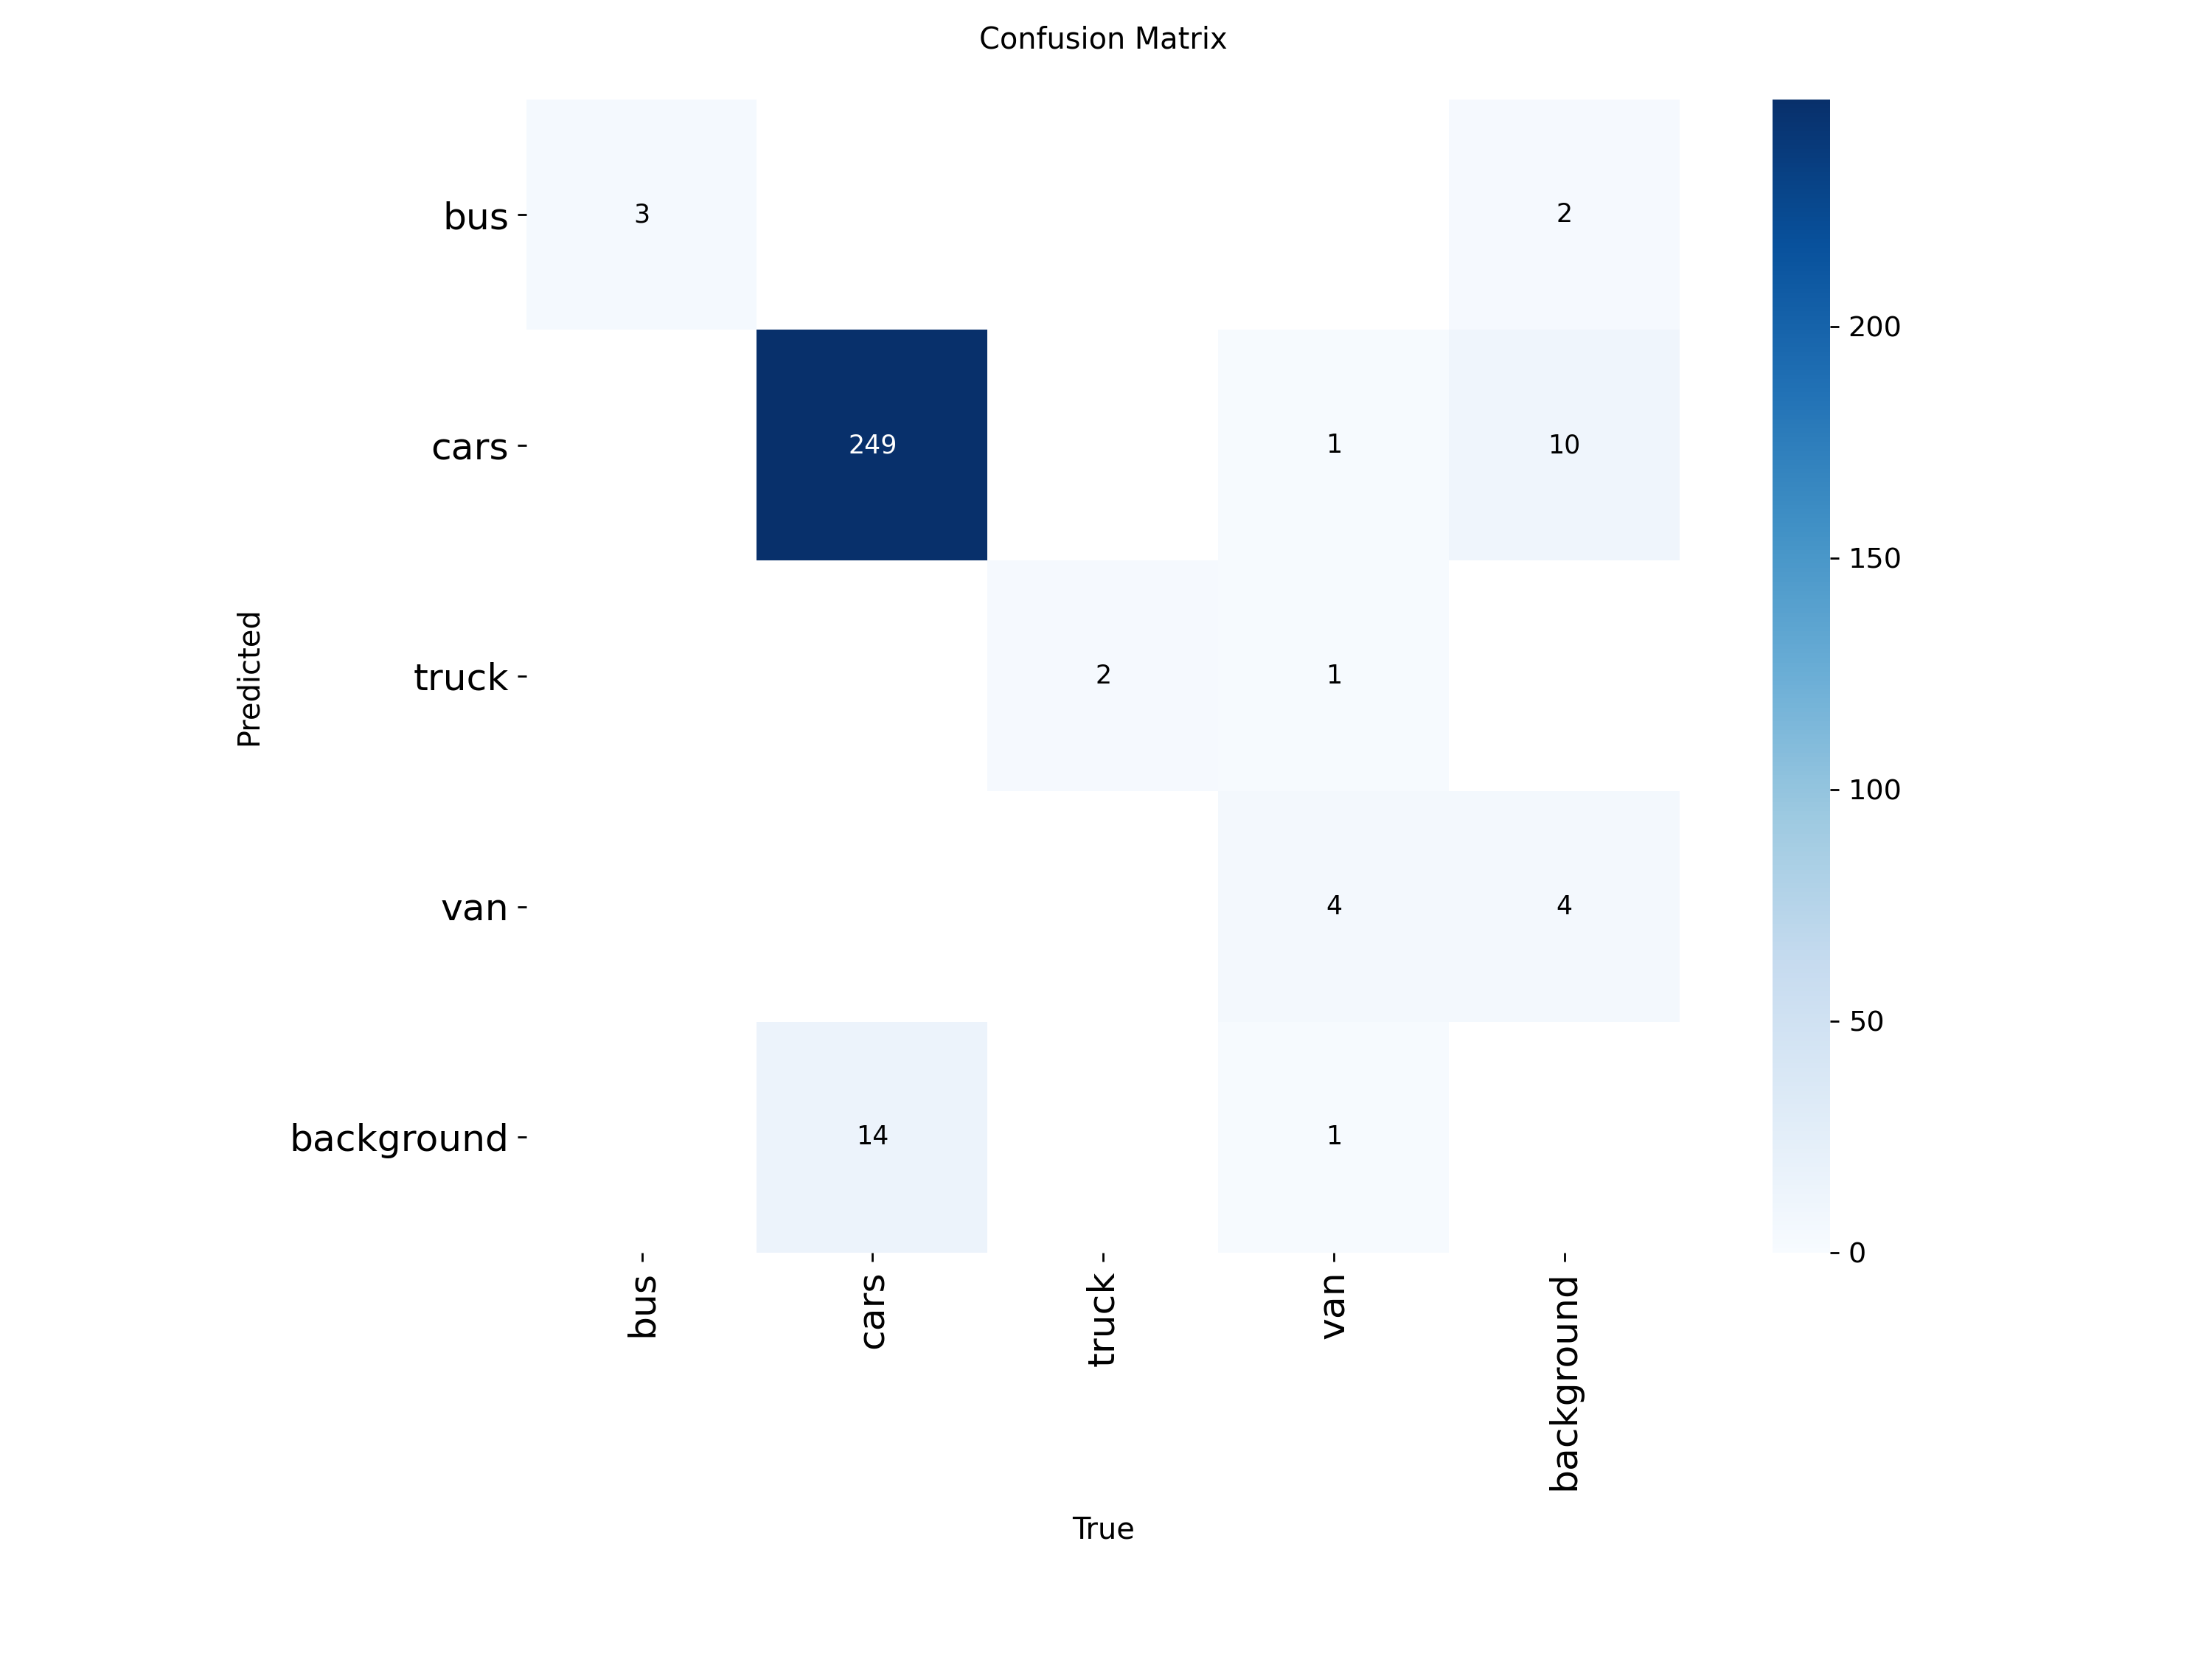

In [14]:
display(Image(filename=f"/kaggle/working/runs/detect/train5/confusion_matrix.png", width=1000))

In [15]:
!yolo task=detect mode=predict model=/kaggle/working/runs/detect/train5/weights/best.pt imgsz=640 conf=0.5 \
source=/kaggle/working/Detecting-Vehicles-on-Aerial-Images-8/valid/images

Ultralytics 8.3.233 🚀 Python-3.11.13 torch-2.3.0+cu118 CUDA:0 (Tesla P100-PCIE-16GB, 16269MiB)
YOLO11s summary (fused): 100 layers, 9,414,348 parameters, 0 gradients, 21.3 GFLOPs

image 1/16 /kaggle/working/Detecting-Vehicles-on-Aerial-Images-8/valid/images/city-3-10_jpg.rf.2dfd83456bdab714d17f5dce21f6fb21.jpg: 384x640 8 carss, 68.4ms
image 2/16 /kaggle/working/Detecting-Vehicles-on-Aerial-Images-8/valid/images/city-3-10_jpg.rf.57dd1ca4219b2d4bff4124436b668d42.jpg: 384x640 12 carss, 7.8ms
image 3/16 /kaggle/working/Detecting-Vehicles-on-Aerial-Images-8/valid/images/city-3-10_jpg.rf.64660ffa4781986d208cae6033175f2a.jpg: 384x640 9 carss, 7.8ms
image 4/16 /kaggle/working/Detecting-Vehicles-on-Aerial-Images-8/valid/images/city-3-10_jpg.rf.834eae8f7121c25e9a4153b05c19a544.jpg: 384x640 22 carss, 7.7ms
image 5/16 /kaggle/working/Detecting-Vehicles-on-Aerial-Images-8/valid/images/city-3-11_jpg.rf.474f3f32d026c860cc073dc7bdfd17d7.jpg: 384x640 23 carss, 7.8ms
image 6/16 /kaggle/working/Detecting

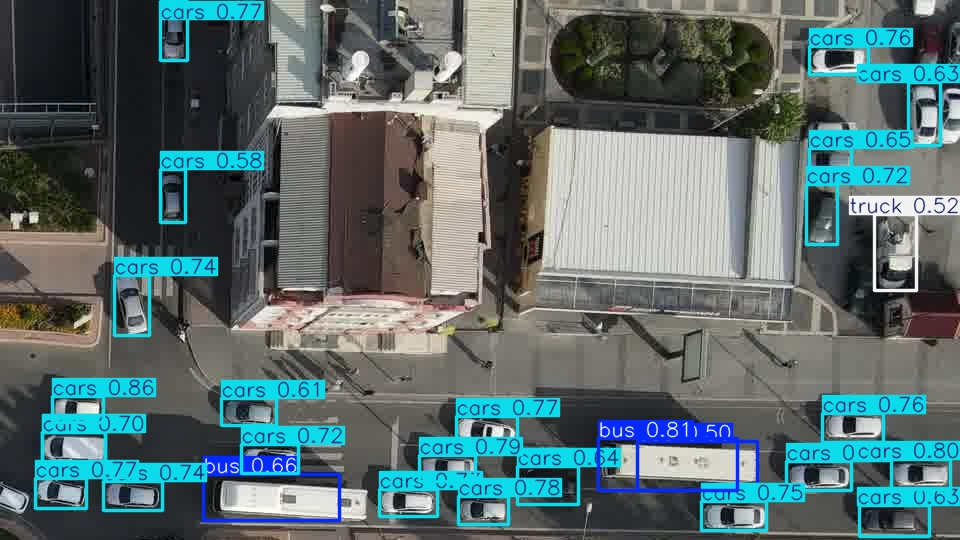

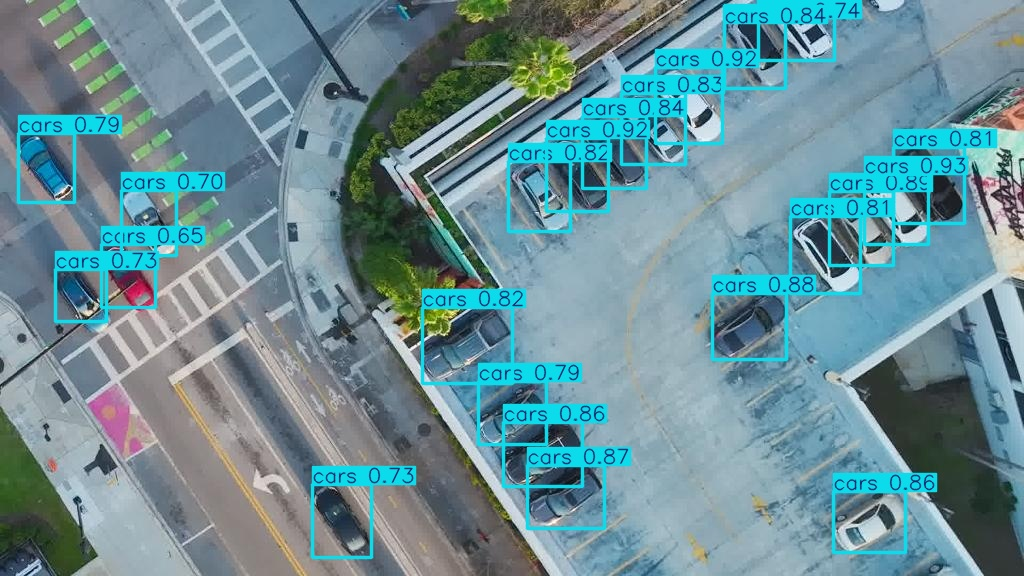

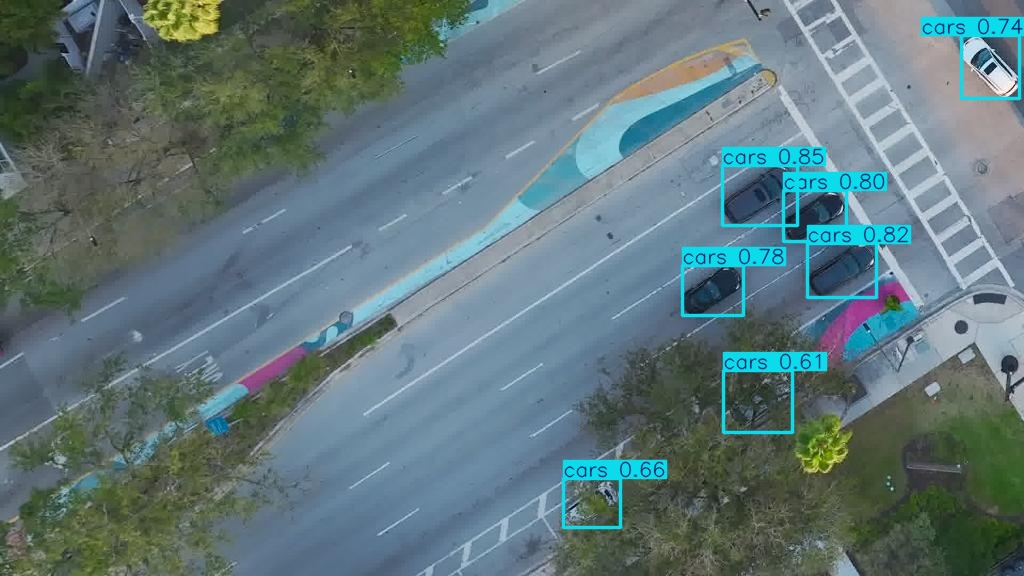

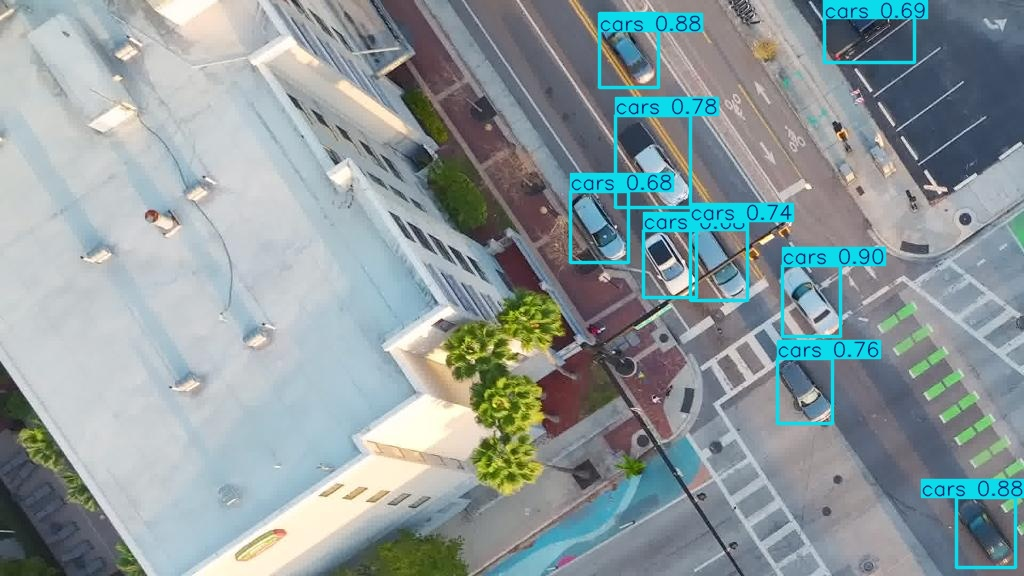

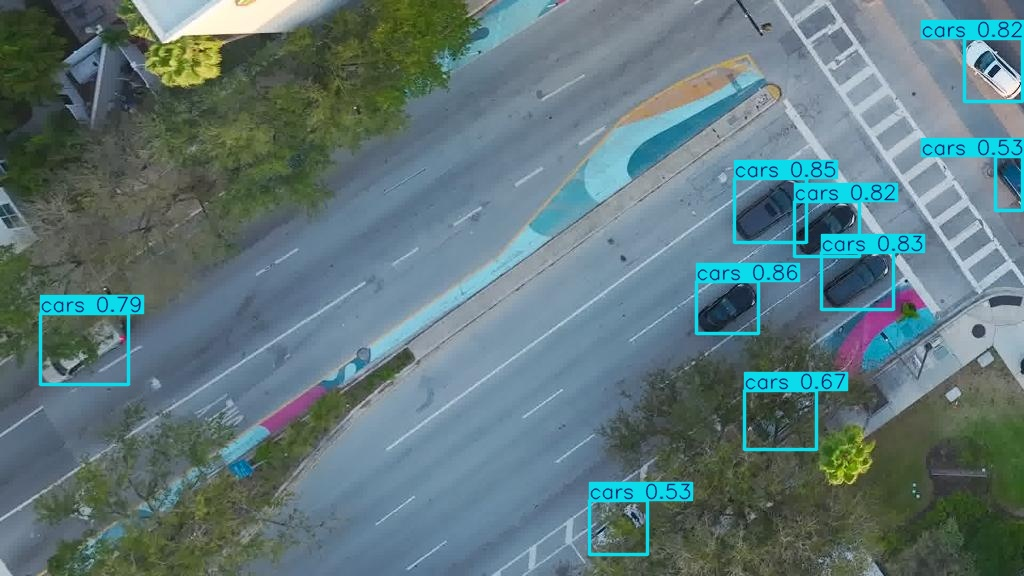

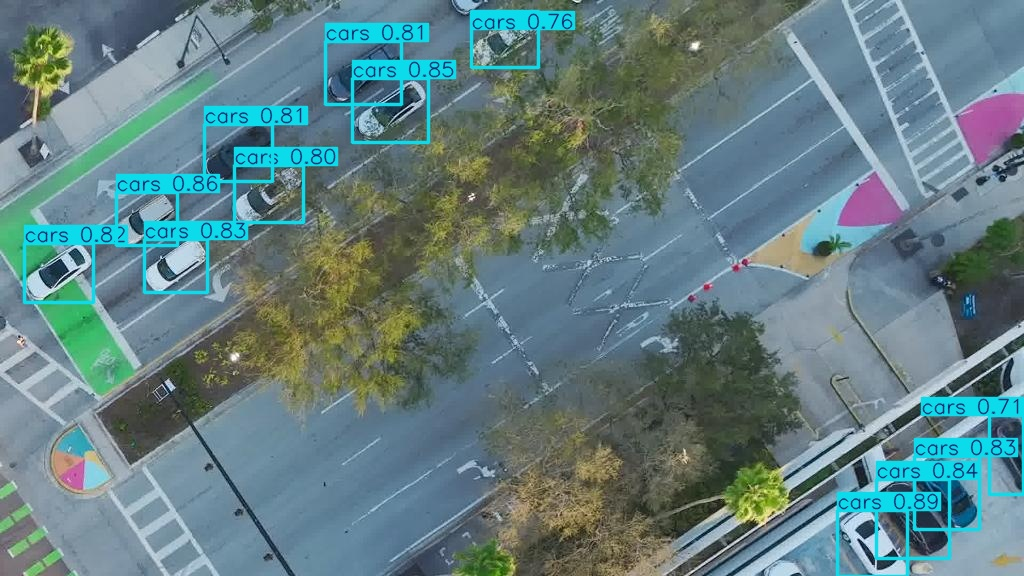

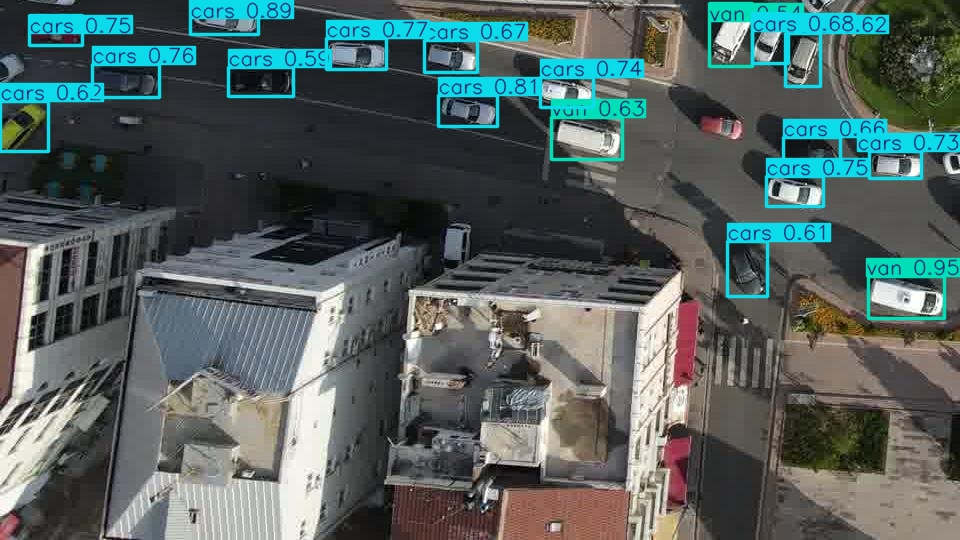

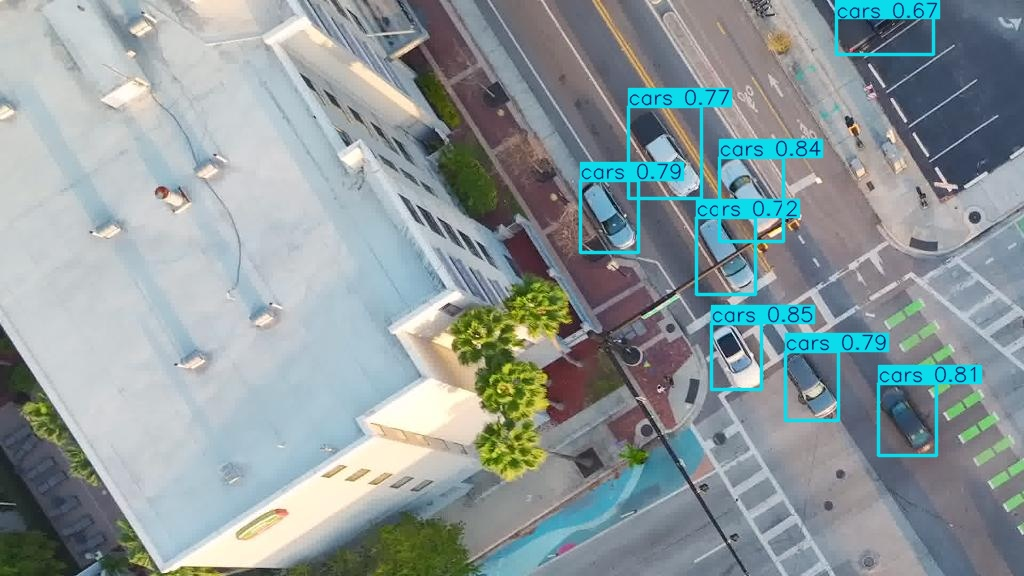

In [16]:
# Display inference on ALL test images
import glob
from IPython.display import Image, display


for imageName in glob.glob("/kaggle/working/runs/detect/predict/*.jpg")[2:10] :#assuming JPG
    print("\n")
    display(Image(filename=imageName))